# 02 - Baseline Simulation

Implements the baseline paper-style logic: fixed production command, no adaptive control, and no prediction.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
STEPS = 600
RUNS = 150
config = SimulationConfig()
engine = SimulationEngine(config=config)
baseline_df = engine.run(steps=STEPS, runs=RUNS, mode='baseline', seed=2026)
baseline_time = summarize_by_time(baseline_df)
print('Rows:', len(baseline_df))
print(performance_summary(baseline_df))
baseline_df.head()

Rows: 90000
{'mean_reliability': 0.5514222222222223, 'failure_rate': 0.4485777777777778, 'mean_production': 0.8725848006056633, 'production_variance': 0.04923951228250867, 'mean_accuracy': 0.43422124106707893, 'mean_load': 6.677571080477136, 'mean_throughput': 0.3682852134903935}


,unit_state_vector,unit_state_mean,gamma,planned_production,production_rate,throughput,transmission_accuracy,reliability,failure,avg_load,max_load,gateway_load,gateway_utilization,avg_utilization,max_utilization,overload_risk,congestion_memory,time,run,mode
0,"[2, 3, 2, 2]",2.25,1.25,5.4375,1.023459,0.292816,0.286104,1.0,0.0,3.378821,8.773827,8.773827,1.438332,1.153797,1.438332,0.438332,0.030393,0,0,baseline
1,"[3, 3, 2, 1]",2.25,1.25,5.3125,1.012800,0.289728,0.286067,1.0,0.0,3.357048,8.649425,8.649425,1.417938,1.152917,1.417938,0.417938,0.057127,1,0,baseline
2,"[2, 3, 1, 0]",1.50,1.25,3.6250,1.001987,0.383788,0.383027,1.0,0.0,2.781317,7.146211,7.146211,1.171510,0.956557,1.300233,0.300233,0.063056,2,0,baseline
3,"[2, 1, 1, 0]",1.00,1.25,2.6250,0.971925,0.422488,0.434692,1.0,0.0,2.499738,6.543024,6.543024,1.072627,0.853457,1.087912,0.087912,0.055834,3,0,baseline
4,"[2, 1, 2, 2]",1.75,1.25,4.4375,1.032406,0.334893,0.324381,1.0,0.0,3.075314,7.984173,7.984173,1.308881,1.052254,1.308881,0.308881,0.061924,4,0,baseline


In [3]:
baseline_df.to_csv(DATASET_DIR / 'baseline_raw_runs.csv', index=False)
baseline_time.to_csv(DATASET_DIR / 'baseline_time_summary.csv', index=False)
print('Saved baseline outputs to', DATASET_DIR)

Saved baseline outputs to /Users/ketantripathi/codes/ICC/iot_project/outputs/datasets


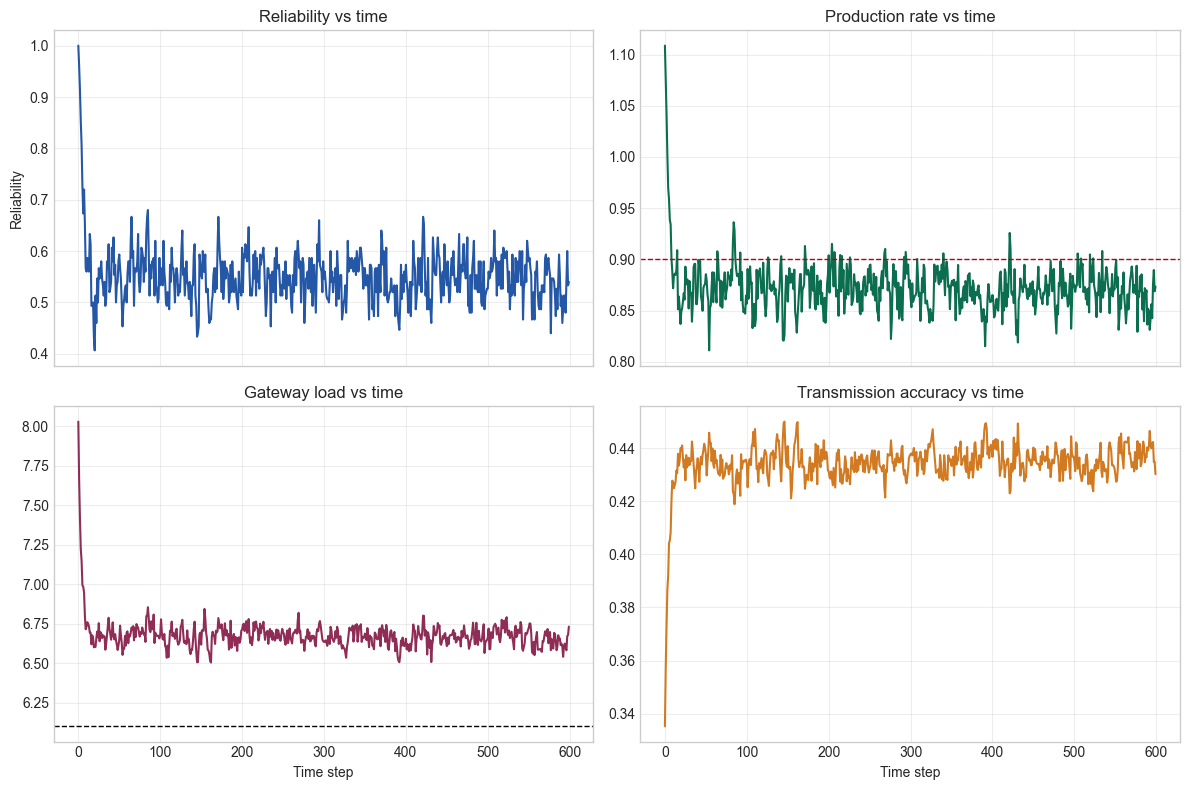

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()
axes[0].plot(baseline_time['time'], baseline_time['reliability'], color='#2457a6')
axes[0].set_title('Reliability vs time')
axes[0].set_ylabel('Reliability')
axes[1].plot(baseline_time['time'], baseline_time['production_rate'], color='#0b6e4f')
axes[1].axhline(config.demand, color='#b00020', linestyle='--', linewidth=1)
axes[1].set_title('Production rate vs time')
axes[2].plot(baseline_time['time'], baseline_time['gateway_load'], color='#8f2d56')
axes[2].axhline(config.gateway_capacity, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Gateway load vs time')
axes[2].set_xlabel('Time step')
axes[3].plot(baseline_time['time'], baseline_time['transmission_accuracy'], color='#d17a22')
axes[3].set_title('Transmission accuracy vs time')
axes[3].set_xlabel('Time step')
for ax in axes:
    ax.grid(True, alpha=0.35)
fig.tight_layout()
fig.savefig(GRAPH_DIR / '02_baseline_performance.png', dpi=160)
plt.show()